In [39]:
import pandas as pd
import numpy as np

from vollib.black_scholes.implied_volatility import implied_volatility

from py_vollib.black_scholes.greeks.analytical import delta
from py_vollib.black_scholes.greeks.analytical import gamma
from py_vollib.black_scholes.greeks.analytical import theta
from py_vollib.black_scholes.greeks.analytical import vega
from py_vollib.black_scholes.greeks.analytical import rho

import xgboost as xgb


from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


from datetime import datetime as dt

import plotly.express as px 

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

%matplotlib inline

In [8]:
df_spot = pd.read_parquet(
    r"C:\Users\shubh\Desktop\Jupyter Notebooks\Data\Junomoneta\spots_2026\spots\nifty_minute_spot_May.gzip"
)

df_strike = pd.read_parquet(
    r"C:\Users\shubh\Desktop\Jupyter Notebooks\Data\Junomoneta\strikes_2026\strikes\nifty_minute_May.gzip"
)

df_vix = pd.read_csv(r"C:\Users\shubh\Desktop\Jupyter Notebooks\Data\Junomoneta\vix\hist_vix_28-03-2026-to-28-06-2026.csv")
df_spot.head()

,symbol,Open,High,Low,Close,Volume,Datetime,time
0,NIFTY_50,24102.50,24245.85,24061.85,24182.45,13613043.0,2026-05-04 09:15:00,09:15:00
1,NIFTY_50,24182.50,24205.85,24162.40,24187.75,7245410.0,2026-05-04 09:16:00,09:16:00
2,NIFTY_50,24181.05,24196.05,24155.15,24156.15,3708794.0,2026-05-04 09:17:00,09:17:00
3,NIFTY_50,24158.15,24200.55,24158.15,24192.80,3878916.0,2026-05-04 09:18:00,09:18:00
4,NIFTY_50,24192.70,24194.55,24169.40,24177.05,3554416.0,2026-05-04 09:19:00,09:19:00


In [9]:
df_strike.head()

,symbol,Datetime,time,Expiry_date,Open,High,Low,Close,Volume,OpenInterest,CE/PE,StrikePrice
0,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-05,1174.0,1295.4,1174.0,1260.00,2925.0,247650.0,CE,23000.0
1,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,726.7,763.3,716.2,731.65,6890.0,187525.0,CE,23800.0
2,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,738.7,738.7,681.9,701.65,1105.0,23205.0,CE,23850.0
3,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,628.0,700.3,628.0,660.15,10790.0,277745.0,CE,23900.0
4,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,618.0,635.9,617.9,623.95,650.0,33020.0,CE,23950.0


In [10]:
df_vix.head()

,Date,Open,High,Low,Close,Prev. Close,Change,% Change
0,30-MAR-2026,26.8025,28.9075,26.8025,27.89,26.8025,1.09,4.06
1,01-APR-2026,27.8875,27.8875,23.6475,25.01,27.8875,-2.88,-10.32
2,02-APR-2026,25.0100,26.5950,25.0100,25.52,25.0100,0.51,2.04
3,06-APR-2026,25.5200,26.5600,25.0825,25.47,25.5200,-0.05,-0.20
4,07-APR-2026,25.4675,26.2550,24.5450,24.70,25.4675,-0.77,-3.01


### EDA

In [11]:
df_strike[(df_strike['StrikePrice'] >= 23000.0) & (df_strike['StrikePrice'] <= 24200.0) &  (df_strike['Datetime'] == '2026-05-04 09:15:00')].sort_values(
    by=['StrikePrice','Close','Volume'], ascending=False)

,symbol,Datetime,time,Expiry_date,Open,High,Low,Close,Volume,OpenInterest,CE/PE,StrikePrice
96,NIFTY,2026-05-04 09:15:00,09:15:00,2026-06-30,677.20,767.45,677.20,734.70,975.0,115895.0,CE,24200.0
111,NIFTY,2026-05-04 09:15:00,09:15:00,2026-06-02,534.35,534.60,514.70,533.65,520.0,8060.0,CE,24200.0
1453229,NIFTY,2026-05-04 09:15:00,09:15:00,2026-06-30,592.70,592.70,515.95,519.95,260.0,136175.0,PE,24200.0
9,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,452.40,499.85,430.00,464.95,116220.0,1197820.0,CE,24200.0
39,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-19,360.00,420.35,352.85,399.05,6305.0,58630.0,CE,24200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1453294,NIFTY,2026-05-04 09:15:00,09:15:00,2026-06-02,126.00,126.00,115.15,115.90,390.0,27170.0,PE,23000.0
1453167,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,112.00,114.80,80.05,89.15,55120.0,3223285.0,PE,23000.0
1453207,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-19,60.00,60.00,49.95,55.65,6240.0,210925.0,PE,23000.0
1453389,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-12,20.40,34.65,17.35,21.90,124930.0,1227005.0,PE,23000.0


In [12]:
df_strike[(df_strike['Datetime'] == '2026-05-04 09:15:00') & (df_strike['Expiry_date'] == '2026-05-26')& (df_strike['CE/PE'] == 'CE')].sort_values(by=['StrikePrice'], ascending=True).head()

,symbol,Datetime,time,Expiry_date,Open,High,Low,Close,Volume,OpenInterest,CE/PE,StrikePrice
59,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,2197.00,2197.00,2197.00,2197.00,65.0,960115.0,CE,22000.0
60,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,1855.00,1855.00,1815.85,1815.85,195.0,319085.0,CE,22500.0
32,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,1398.00,1411.55,1365.60,1379.10,3120.0,798395.0,CE,23000.0
46,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,1248.00,1248.00,1248.00,1248.00,65.0,17550.0,CE,23100.0
31,NIFTY,2026-05-04 09:15:00,09:15:00,2026-05-26,890.35,998.75,890.35,956.85,8710.0,695890.0,CE,23500.0


### Data Cleaning & Filtering

In [13]:
df_strike['Datetime'] = pd.to_datetime(df_strike['Datetime'])
df_strike['Datetime'].head(2)

0   2026-05-04 09:15:00
1   2026-05-04 09:15:00
Name: Datetime, dtype: datetime64[us]

In [14]:
filtered_strike = df_strike[df_strike['Datetime'].dt.day == df_strike['Expiry_date'].dt.day]

filtered_strike.reset_index(drop=True,inplace=True)

In [15]:
filtered_strike.groupby('Datetime').head()

,symbol,Datetime,time,Expiry_date,Open,High,Low,Close,Volume,OpenInterest,CE/PE,StrikePrice
0,NIFTY,2026-05-05 09:15:00,09:15:00,2026-05-05,0.85,0.85,0.50,0.55,7265570.0,15997995.0,CE,25000.0
1,NIFTY,2026-05-05 09:15:00,09:15:00,2026-05-05,0.80,0.80,0.45,0.50,505115.0,2270515.0,CE,25050.0
2,NIFTY,2026-05-05 09:15:00,09:15:00,2026-05-05,0.70,0.80,0.40,0.45,1188330.0,4752540.0,CE,25100.0
3,NIFTY,2026-05-05 09:15:00,09:15:00,2026-05-05,0.70,0.70,0.40,0.45,440115.0,1524445.0,CE,25150.0
4,NIFTY,2026-05-05 09:15:00,09:15:00,2026-05-05,0.60,0.65,0.35,0.35,1485250.0,7140250.0,CE,25200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
193642,NIFTY,2026-05-29 11:46:00,11:46:00,2026-09-29,27.00,27.00,27.00,27.00,65.0,188760.0,PE,18000.0
193777,NIFTY,2026-05-29 11:59:00,11:59:00,2026-09-29,86.45,87.00,86.45,87.00,585.0,669045.0,PE,21000.0
194124,NIFTY,2026-05-29 12:29:00,12:29:00,2026-09-29,89.70,89.90,89.70,89.90,1300.0,676260.0,PE,21000.0
194125,NIFTY,2026-05-29 12:29:00,12:29:00,2026-12-29,185.10,185.10,185.10,185.10,65.0,704650.0,PE,21000.0


In [16]:
mask = filtered_strike['Expiry_date'].dt.day

df_spot = df_spot[df_spot['Datetime'].dt.day.isin(mask)].reset_index()

In [17]:
merged_df = pd.merge(filtered_strike, df_spot, on='Datetime', how='inner')
merged_df.drop(columns=['index','symbol_y','Open_y','Low_y', 'High_y','Volume_y'], inplace=True)

In [18]:
df_vix['Date'] = pd.to_datetime(df_vix['Date '])
df_vix.drop(columns=['Date '], inplace=True)

merged_df['Date'] = merged_df['Datetime'].dt.strftime("%Y-%m-%d")
# merged_df.drop(columns=['Datetime'], inplace=True)

C:\Users\shubh\AppData\Local\Temp\ipykernel_5828\3992485639.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_vix['Date'] = pd.to_datetime(df_vix['Date '])


In [19]:
df_vix.columns

Index(['Open ', 'High ', 'Low ', 'Close ', 'Prev. Close ', 'Change ',
       '% Change ', 'Date'],
      dtype='object')

In [20]:
merged_df['Date'] = pd.to_datetime(merged_df['Date']).dt.normalize()
df_vix['Date']    = pd.to_datetime(df_vix['Date']).dt.normalize()

df_vix = df_vix.rename(columns={
    'Open ':       'VIX_Open',
    'High ':       'VIX_High',
    'Low ':        'VIX_Low',
    'Close ':      'VIX_Close',
    'Prev. Close ':'VIX_Prev_Close',
    'Change ':     'VIX_Change',
    '% Change ':   'VIX_Pct_Change'
})

merged_df = pd.merge(merged_df, df_vix[['Date', 'VIX_Close']], on='Date', how='left')

merged_df['VIX_decimal'] = merged_df['VIX_Close'] / 100

In [21]:
merged_df.reset_index(drop=True, inplace=True)
df_final = merged_df[abs(merged_df['StrikePrice'] - merged_df['Close_y']) <= (merged_df['Close_y'] * 1 / 100)]

In [22]:
df_final.head()

,symbol_x,Datetime,time_x,Expiry_date,Open_x,High_x,Low_x,Close_x,Volume_x,OpenInterest,CE/PE,StrikePrice,Close_y,time_y,Date,VIX_Close,VIX_decimal
35,NIFTY,2026-05-05 09:15:00,09:15:00,2026-05-05,263.0,265.8,161.15,218.85,421200.0,574990.0,CE,23800.0,24008.5,09:15:00,2026-05-05,17.91,0.1791
41,NIFTY,2026-05-05 09:15:00,09:15:00,2026-05-05,223.0,227.3,123.60,177.85,274235.0,353535.0,CE,23850.0,24008.5,09:15:00,2026-05-05,17.91,0.1791
51,NIFTY,2026-05-05 09:15:00,09:15:00,2026-05-05,187.6,199.0,90.80,133.20,1584830.0,774540.0,CE,23900.0,24008.5,09:15:00,2026-05-05,17.91,0.1791
52,NIFTY,2026-05-05 09:15:00,09:15:00,2026-05-05,100.0,125.0,43.10,72.35,10941060.0,3557190.0,CE,24000.0,24008.5,09:15:00,2026-05-05,17.91,0.1791
59,NIFTY,2026-05-05 09:15:00,09:15:00,2026-05-05,148.0,153.0,63.65,102.30,3311880.0,358020.0,CE,23950.0,24008.5,09:15:00,2026-05-05,17.91,0.1791


In [23]:
def calculate_greeks(row):
    S      = row["Close_y"]
    K      = row["StrikePrice"]
    price  = row["Close_x"]
    flag   = "c" if row["CE/PE"] == "CE" else "p"
    r      = 0.06
    vix_iv = row["VIX_decimal"]   # <-- pulled from the merged column

    expiry = pd.Timestamp(row["Expiry_date"].strftime("%Y-%m-%d") + " 15:30:00")
    t      = (expiry - row["Datetime"]).total_seconds() / (365 * 24 * 60 * 60)

    if t <= 0:
        is_itm = (flag == "c" and S > K) or (flag == "p" and S < K)
        return pd.Series({
            "IV": 0.0,
            "Delta": (1.0 if is_itm else 0.0) if flag == "c" else (-1.0 if is_itm else 0.0),
            "Gamma": 0.0, "Theta": 0.0, "Vega": 0.0, "Rho": 0.0
        })

    t_min  = 30 / (365 * 24 * 60 * 60)
    t_calc = max(t, t_min)

    discount_factor = np.exp(-r * t_calc)
    lower_bound = max(S - K * discount_factor, 0.0) if flag == "c" else max(K * discount_factor - S, 0.0)

    if price <= lower_bound:
        price = lower_bound + 0.05

    try:
        iv = implied_volatility(price, S, K, t_calc, r, flag)

        # Use VIX as the floor instead of 0.0001
        if pd.isna(iv) or iv <= 0.0:
            iv = vix_iv

        return pd.Series({
            "IV":    iv,
            "Delta": delta(flag, S, K, t_calc, r, iv),
            "Gamma": gamma(flag, S, K, t_calc, r, iv),
            "Theta": theta(flag, S, K, t_calc, r, iv),
            "Vega":  vega(flag, S, K, t_calc, r, iv),
            "Rho":   rho(flag, S, K, t_calc, r, iv)
        })

    except Exception:
        is_itm    = (flag == "c" and S > K) or (flag == "p" and S < K)
        delta_val = (1.0 if is_itm else 0.0) if flag == "c" else (-1.0 if is_itm else 0.0)
        return pd.Series({
            "IV": vix_iv,   # <-- realistic fallback, not 0.0001
            "Delta": delta_val,
            "Gamma": 0.0, "Theta": 0.0, "Vega": 0.0, "Rho": 0.0
        })

df_final[["IV","Delta","Gamma","Theta","Vega","Rho"]] = df_final.apply(calculate_greeks, axis=1)

C:\Users\shubh\AppData\Local\Temp\ipykernel_5828\2165468813.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[["IV","Delta","Gamma","Theta","Vega","Rho"]] = df_final.apply(calculate_greeks, axis=1)
C:\Users\shubh\AppData\Local\Temp\ipykernel_5828\2165468813.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[["IV","Delta","Gamma","Theta","Vega","Rho"]] = df_final.apply(calculate_greeks, axis=1)
C:\Users\shubh\AppData\Local\Temp\ipykernel_5828\2165468813.py:54: SettingWithCopyWarning: 


In [28]:
# df_final = df_final.dropna()
df_final.columns

Index(['symbol_x', 'Datetime', 'time_x', 'Expiry_date', 'Open_x', 'High_x',
       'Low_x', 'Close_x', 'Volume_x', 'OpenInterest', 'CE/PE', 'StrikePrice',
       'Close_y', 'time_y', 'Date', 'VIX_Close', 'VIX_decimal', 'IV', 'Delta',
       'Gamma', 'Theta', 'Vega', 'Rho'],
      dtype='object')

### Data Vislualization

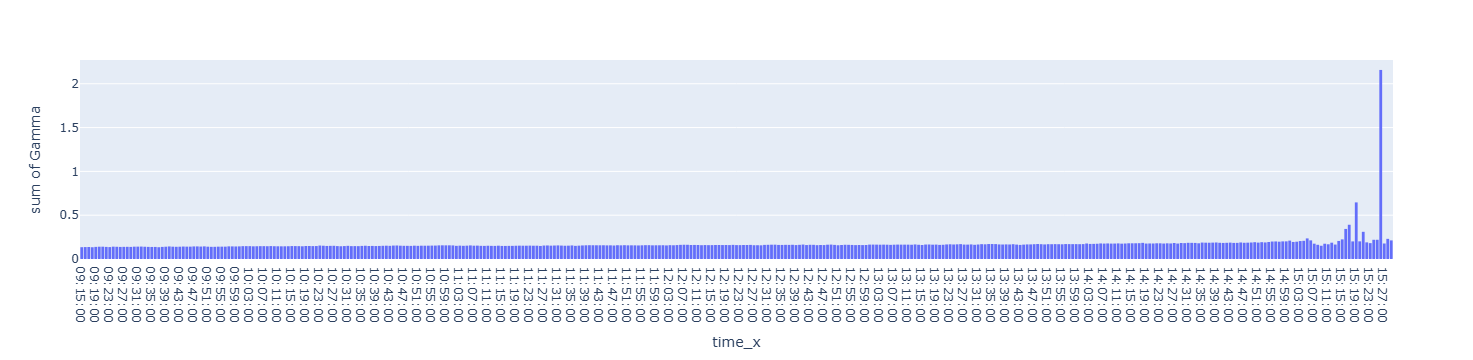

In [25]:
px.histogram(df_final,  x='time_x', y='Gamma' , nbins=375)

In [179]:
# fig = px.scatter(df_final, x='time_x', y='Gamma', title='Gamma per minute')

# fig.update_traces(marker=dict(size=16, line=dict(width=2, color='DarkSlateGrey')),
#                  selector=dict(mode='markets'))

# fig.show()

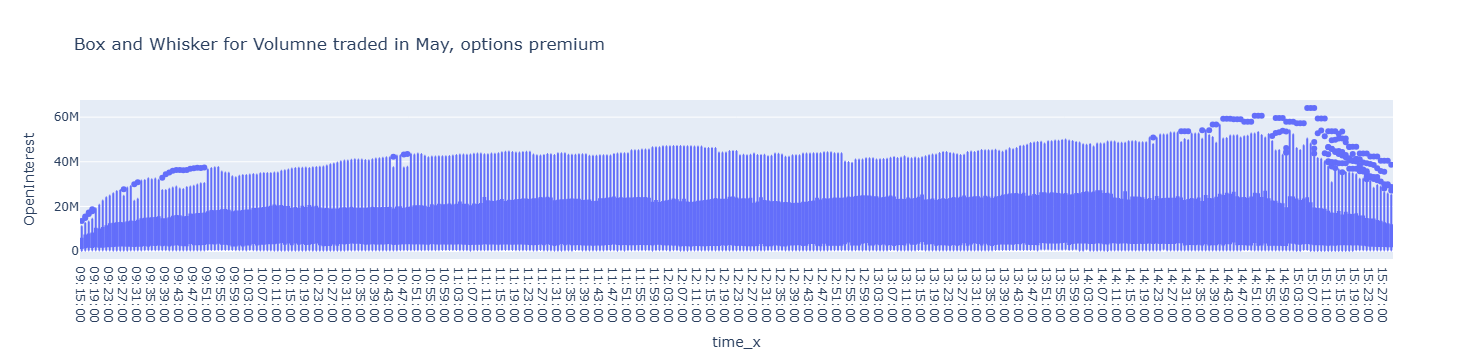

In [180]:
px.box(df_final, x = 'time_x', y = 'OpenInterest', title='Box and Whisker for Volumne traded in May, options premium', hover_data=['Gamma'])

In [110]:
# px.bar(df_final, x='time_x', y='Theta', color='Gamma')

### Gamma Blast Detection model

In [64]:
def add_gamma_blast_label(df):
    """
    For each option, check if premium doubles in next 10 minutes.
    label = 1 if max(High in next 10 min) >= 2 * current Close
    """
    df = df.sort_values(['symbol', 'Expiry_date', 'StrikePrice', 'CE/PE', 'Datetime'])
    
    df['option_id'] = (df['symbol'].astype(str) + '_' + 
                       df['Expiry_date'].astype(str) + '_' + 
                       df['StrikePrice'].astype(str) + '_' + 
                       df['CE/PE'].astype(str))
    
    for i in range(1, 11):
        df[f'High_plus_{i}'] = df.groupby('option_id')['High_x'].shift(-i)
    
    high_cols = [f'High_plus_{i}' for i in range(1, 11)]
    df['max_high_next10'] = df[high_cols].max(axis=1)
    
    df['label'] = (df['max_high_next10'] >= 2 * df['Close_x']).astype(int)
    
    df = df.dropna(subset=['max_high_next10']).copy()
    
    df.drop(columns=high_cols + ['max_high_next10', 'option_id'], inplace=True, errors='ignore')
    
    return df

df_labeled = add_gamma_blast_label(df_all)
print(f"Labeled data shape: {df_labeled.shape}")
print(f"Gamma blast %: {df_labeled['label'].mean()*100:.2f}%")

Adding gamma blast labels...
Labeled data shape: (57627, 23)
Gamma blast %: 3.59%


In [65]:
def load_month(month_name, vix_df):
    base = r"C:\Users\shubh\Desktop\Jupyter Notebooks\Data\Junomoneta"
    
    spot = pd.read_parquet(f"{base}\\spots_2026\\spots\\nifty_minute_spot_{month_name}.gzip")
    strike = pd.read_parquet(f"{base}\\strikes_2026\\strikes\\nifty_minute_{month_name}.gzip")
    
    spot['Datetime'] = pd.to_datetime(spot['Datetime'])
    strike['Datetime'] = pd.to_datetime(strike['Datetime'])
    strike['Expiry_date'] = pd.to_datetime(strike['Expiry_date'])
    
    filtered = strike[strike['Datetime'].dt.day == strike['Expiry_date'].dt.day].copy()
    filtered.reset_index(drop=True, inplace=True)
    
    spot = spot[spot['Datetime'].dt.day.isin(filtered['Expiry_date'].dt.day)].reset_index(drop=True)
    
    merged = pd.merge(filtered, spot, on='Datetime', how='inner', suffixes=('_strike', '_spot'))
    
    cols_to_drop = ['symbol_spot', 'Open_spot', 'Low_spot', 'High_spot', 'Volume_spot', 'time_spot']
    merged.drop(columns=[col for col in cols_to_drop if col in merged.columns], inplace=True, errors='ignore')
    
    merged.rename(columns={
        'symbol_strike': 'symbol',
        'Open_strike': 'Open_x',
        'High_strike': 'High_x',
        'Low_strike': 'Low_x',
        'Close_strike': 'Close_x',
        'Volume_strike': 'Volume_x',
        'time_strike': 'time_x',
        'Close_spot': 'Close_y'
    }, inplace=True)
    
    # Add VIX
    merged['Date'] = pd.to_datetime(merged['Datetime'].dt.strftime("%Y-%m-%d"))
    merged = pd.merge(merged, vix_df[['Date', 'VIX_Close']], on='Date', how='left')
    merged['VIX_decimal'] = merged['VIX_Close'] / 100
    
    merged = merged[abs(merged['StrikePrice'] - merged['Close_y']) <= (merged['Close_y'] * 0.01)]
    
    return merged.reset_index(drop=True)


vix_raw = pd.read_csv(r"C:\Users\shubh\Desktop\Jupyter Notebooks\Data\Junomoneta\vix\hist_vix_28-03-2026-to-28-06-2026.csv")

vix_raw.columns = vix_raw.columns.str.strip()

# Create clean VIX dataframe
vix_df = pd.DataFrame({
    'Date': pd.to_datetime(vix_raw['Date'], format='%d-%b-%Y'),
    'VIX_Close': vix_raw['Close']
})

# Extend VIX to June 30th (carry forward last value)
last_date = vix_df['Date'].max()
last_close = vix_df.loc[vix_df['Date'].idxmax(), 'VIX_Close']
extra_dates = pd.DataFrame({
    'Date': pd.date_range(last_date + pd.Timedelta(days=1), '2026-06-30', freq='D'),
    'VIX_Close': last_close
})
vix_df = pd.concat([vix_df, extra_dates], ignore_index=True)

print("VIX shape:", vix_df.shape)
print("VIX date range:", vix_df['Date'].min(), "to", vix_df['Date'].max())
print(vix_df.tail())


# ---------- Load May and June data ----------
print("Loading May data...")
df_may = load_month('May', vix_df)
print(f"May data shape: {df_may.shape}")

print("Loading June data...")
df_june = load_month('Jun', vix_df)
print(f"June data shape: {df_june.shape}")

# Combine and sort
df_all = pd.concat([df_may, df_june], ignore_index=True)
df_all['Datetime'] = pd.to_datetime(df_all['Datetime'])
df_all.sort_values('Datetime', inplace=True)
df_all.reset_index(drop=True, inplace=True)

print(f"\nTotal combined data shape: {df_all.shape}")
print(f"Date range: {df_all['Datetime'].min()} to {df_all['Datetime'].max()}")
print(f"\nUnique expiry dates: {sorted(df_all['Expiry_date'].unique())}")
print(df_all.head())
print(f"\nColumns: {df_all.columns.tolist()}")

VIX shape: (64, 2)
VIX date range: 2026-03-30 00:00:00 to 2026-06-30 00:00:00
         Date  VIX_Close
59 2026-06-26      13.05
60 2026-06-27      13.05
61 2026-06-28      13.05
62 2026-06-29      13.05
63 2026-06-30      13.05
Loading May data...
May data shape: (29451, 16)
Loading June data...
June data shape: (28407, 16)

Total combined data shape: (57858, 16)
Date range: 2026-05-05 09:15:00 to 2026-06-23 15:29:00

Unique expiry dates: [Timestamp('2026-05-05 00:00:00'), Timestamp('2026-05-12 00:00:00'), Timestamp('2026-05-19 00:00:00'), Timestamp('2026-05-26 00:00:00'), Timestamp('2026-06-02 00:00:00'), Timestamp('2026-06-09 00:00:00'), Timestamp('2026-06-16 00:00:00'), Timestamp('2026-06-23 00:00:00'), Timestamp('2026-09-29 00:00:00'), Timestamp('2026-12-29 00:00:00'), Timestamp('2028-12-26 00:00:00')]

First few rows:
  symbol            Datetime    time_x Expiry_date  Open_x  High_x   Low_x  \
0  NIFTY 2026-05-05 09:15:00  09:15:00  2026-05-05  263.00   265.8  161.15   
1  NIFTY 

In [66]:
df_all[["IV","Delta","Gamma","Theta","Vega","Rho"]] = df_all.apply(calculate_greeks, axis=1)

In [67]:
df_labeled = add_gamma_blast_label(df_all)

In [68]:
df_labeled['minutes_to_expiry'] = (
    (pd.to_datetime(df_labeled['Expiry_date'].astype(str) + ' 15:30:00') - df_labeled['Datetime'])
    .dt.total_seconds() / 60
)

market_open = pd.to_datetime(df_labeled['Datetime'].dt.strftime('%Y-%m-%d') + ' 09:15:00')
df_labeled['minute_of_day'] = (df_labeled['Datetime'] - market_open).dt.total_seconds() / 60


df_labeled['moneyness_ratio'] = df_labeled['StrikePrice'] / df_labeled['Close_y']
df_labeled['moneyness_diff'] = df_labeled['StrikePrice'] - df_labeled['Close_y']

df_labeled['is_call'] = (df_labeled['CE/PE'] == 'CE').astype(int)

feature_cols = [
    'IV', 'Delta', 'Gamma', 'Theta', 'Vega', 'Rho',
    'moneyness_ratio', 'moneyness_diff', 'minutes_to_expiry',
    'minute_of_day', 'VIX_decimal', 'Volume_x', 'OpenInterest', 'is_call'
]

df_model = df_labeled.dropna(subset=feature_cols + ['label']).copy()

In [69]:
test_start = pd.Timestamp('2026-06-16')

train_mask = df_model['Datetime'] < test_start
test_mask = df_model['Datetime'] >= test_start

X_train = df_model.loc[train_mask, feature_cols]
y_train = df_model.loc[train_mask, 'label']
X_test = df_model.loc[test_mask, feature_cols]
y_test = df_model.loc[test_mask, 'label']

print(f"Train: {len(X_train)} rows ({df_model.loc[train_mask, 'Datetime'].min()} to {df_model.loc[train_mask, 'Datetime'].max()})")
print(f"Test:  {len(X_test)} rows ({df_model.loc[test_mask, 'Datetime'].min()} to {df_model.loc[test_mask, 'Datetime'].max()})")
print(f"Blast % - Train: {y_train.mean()*100:.2f}%, Test: {y_test.mean()*100:.2f}%")

Train: 43115 rows (2026-05-05 09:15:00 to 2026-06-09 15:28:00)
Test:  14512 rows (2026-06-16 09:15:00 to 2026-06-23 15:28:00)
Blast % - Train: 3.54%, Test: 3.73%


In [72]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count if pos_count > 0 else 1

print(f"Negative samples: {neg_count}, Positive samples: {pos_count}")
print(f"Scale weight: {scale_weight:.2f}")

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)

print("Training model...")
model.fit(X_train, y_train)
print("Training complete!")

Negative samples: 41590, Positive samples: 1525
Scale weight: 27.27
Training model...
Training complete ✓


In [73]:
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[11887  2084]
 [  283   258]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91     13971
           1       0.11      0.48      0.18       541

    accuracy                           0.84     14512
   macro avg       0.54      0.66      0.54     14512
weighted avg       0.94      0.84      0.88     14512

ROC AUC: 0.7616620962011221
